In [1]:
import numpy as np
import pandas as pd
import os

from pathlib import Path

def resolve_data_dir() -> Path:
    """Locate the dataset locally or on Kaggle."""
    candidates = [
        Path("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"),
        Path("../data"),
        Path("data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    raise FileNotFoundError(
        "Could not find train.csv. Place the CSVs in ../data (from notebooks/) "
        "or keep the default Kaggle input path."
    )

DATA_DIR = resolve_data_dir()
print("Using data directory:", DATA_DIR.resolve())


/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
ss = pd.read_csv(DATA_DIR / "sample_submission.csv")


/tmp/ipykernel_16/3205134266.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


In [3]:
print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")

Train Shape : (138701, 50)
Test Shape  : (15000, 49)


In [4]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
test.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TransactionID              15000 non-null  int64  
 1   AssetID                    15000 non-null  int64  
 2   ProductConfigID            15000 non-null  int64  
 3   DataOriginCode             15000 non-null  object 
 4   VendorPartnerID            15000 non-null  object 
 5   ManufactureYear            15000 non-null  int64  
 6   OperationalHoursMeter      8809 non-null   float64
 7   UtilizationTier            5356 non-null   object 
 8   TransactionDate            15000 non-null  object 
 9   Spec_FullDescriptor        15000 non-null  object 
 10  Spec_BaseClass             15000 non-null  object 
 11  Spec_SubClass              11006 non-null  object 
 12  Spec_ReleaseSeries         3505 non-null   object 
 13  Spec_VariantModifier       5609 non-null   obj

In [8]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


EDA

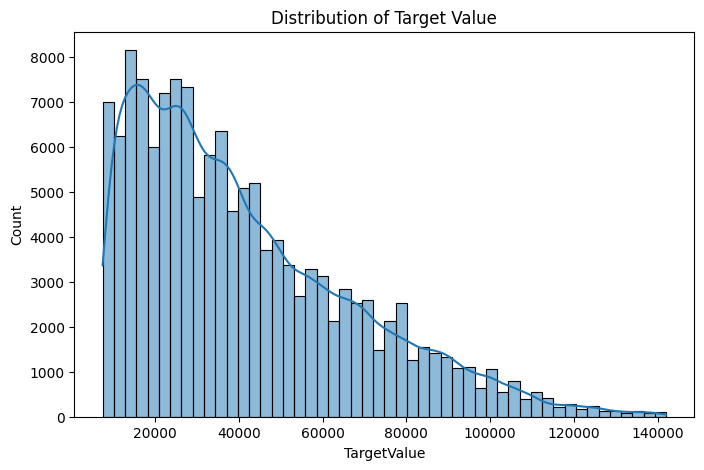

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(train["TargetValue"], bins=50, kde=True)

plt.title("Distribution of Target Value")
plt.show()

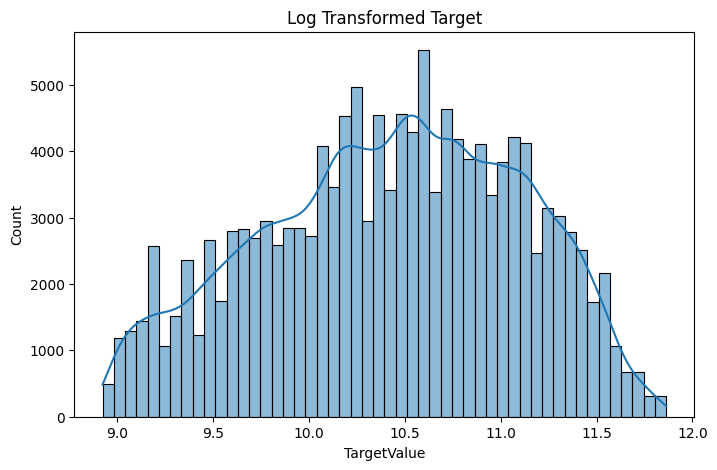

In [10]:
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(train["TargetValue"]), bins=50, kde=True)

plt.title("Log Transformed Target")
plt.show()

In [11]:
missing = (
    train.isnull()
         .mean()
         .mul(100)
         .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing.head(20)

col19                 99.952416
col18                 99.952416
col5                  92.515555
col4                  92.515555
col27                 89.214930
col28                 89.214930
col29                 86.393753
col30                 86.393753
col13                 83.125572
col14                 83.125572
col7                  83.125572
col6                  83.125572
col9                  83.125572
col8                  83.125572
col11                 83.125572
col3                  78.909309
Forks                 78.861724
Spec_ReleaseSeries    76.282795
col1                  75.641127
col12                 72.340502
dtype: float64

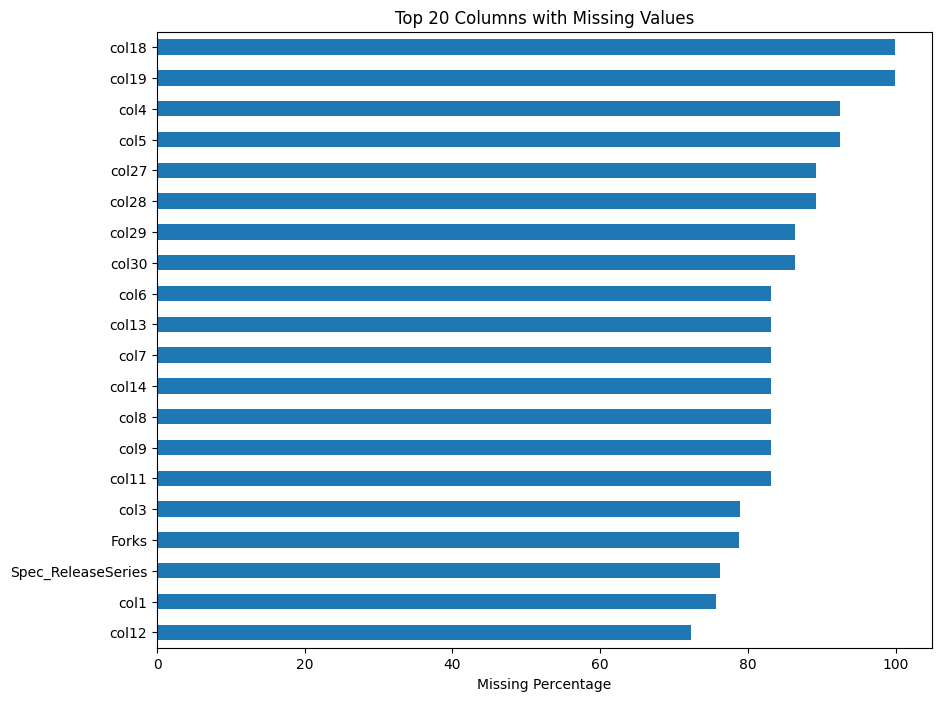

In [12]:
plt.figure(figsize=(10,8))

missing.head(20).sort_values().plot(kind="barh")

plt.xlabel("Missing Percentage")
plt.title("Top 20 Columns with Missing Values")

plt.show()

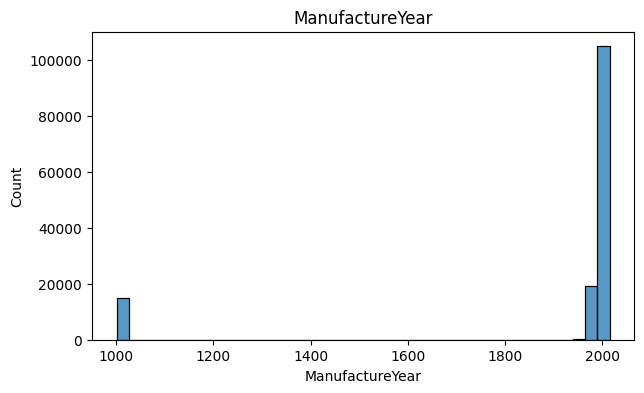

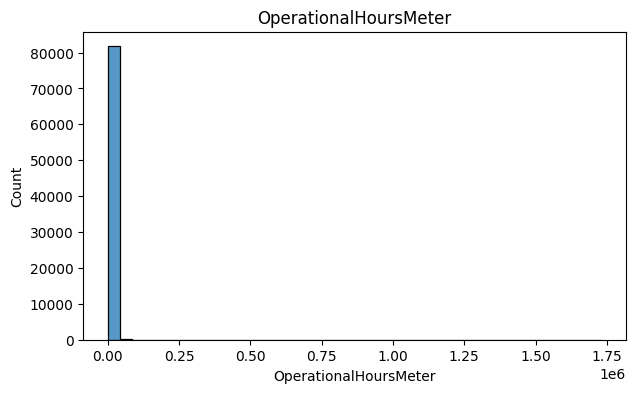

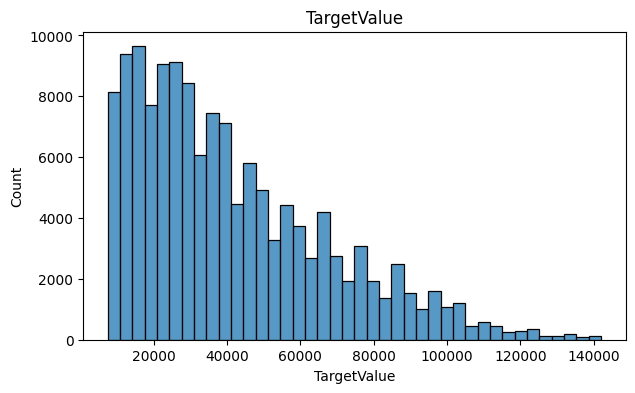

In [13]:
num_cols = [
    "ManufactureYear",
    "OperationalHoursMeter",
    "TargetValue"
]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(train[col], bins=40)
    plt.title(col)
    plt.show()

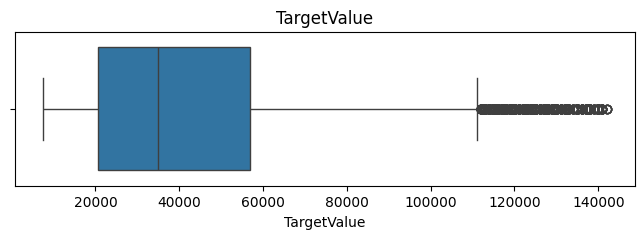

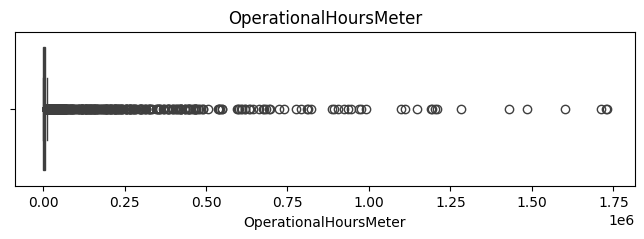

In [14]:
for col in ["TargetValue", "OperationalHoursMeter"]:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

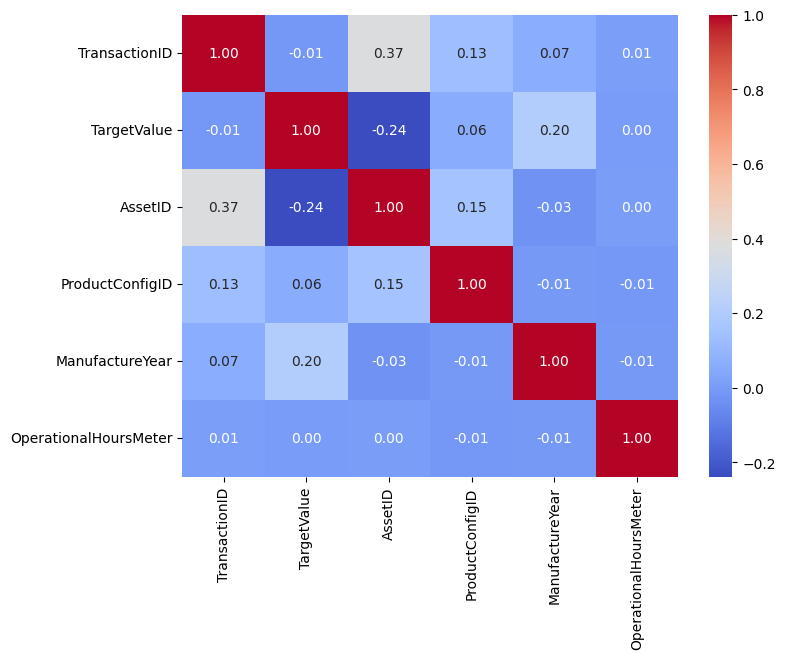

In [15]:
numeric = train.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

feature engineering

In [16]:
train_df = train.copy()
test_df = test.copy()

In [17]:
train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])
test_df["TransactionDate"] = pd.to_datetime(test_df["TransactionDate"])

In [18]:
for df in [train_df, test_df]:
    df["TransactionYear"] = df["TransactionDate"].dt.year
    df["TransactionMonth"] = df["TransactionDate"].dt.month
    df["TransactionQuarter"] = df["TransactionDate"].dt.quarter
    df["TransactionDay"] = df["TransactionDate"].dt.day
    df["TransactionWeekday"] = df["TransactionDate"].dt.weekday

In [19]:
for df in [train_df, test_df]:
    df["MachineAge"] = (
        df["TransactionYear"] -
        df["ManufactureYear"]
    )

In [20]:
for df in [train_df, test_df]:
    df["MachineAge"] = df["MachineAge"].clip(lower=0)

In [21]:
for df in [train_df, test_df]:
    df["DescriptorLength"] = (
        df["Spec_FullDescriptor"]
        .astype(str)
        .str.len()
    )

In [22]:
for df in [train_df, test_df]:
    df["MissingCount"] = df.isnull().sum(axis=1)

In [23]:
train_df.drop(columns=["TransactionDate"], inplace=True)
test_df.drop(columns=["TransactionDate"], inplace=True)

In [24]:
missing_pct = train_df.isnull().mean() * 100

missing_pct.sort_values(ascending=False).head(20)

col18                 99.952416
col19                 99.952416
col5                  92.515555
col4                  92.515555
col28                 89.214930
col27                 89.214930
col30                 86.393753
col29                 86.393753
col6                  83.125572
col8                  83.125572
col7                  83.125572
col11                 83.125572
col9                  83.125572
col14                 83.125572
col13                 83.125572
col3                  78.909309
Forks                 78.861724
Spec_ReleaseSeries    76.282795
col1                  75.641127
col12                 72.340502
dtype: float64

In [25]:
drop_cols = ["col18", "col19"]

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

In [26]:
print(train_df.shape)
print(test_df.shape)

(138701, 55)
(15000, 54)


preprocessing

In [27]:
X = train_df.drop(columns=["TargetValue"])
y = train_df["TargetValue"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
import numpy as np

y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

In [30]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(len(numeric_features))
print(len(categorical_features))

8
41


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [32]:
from sklearn.preprocessing import OrdinalEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1))
])

In [33]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

X_test_processed = preprocessor.transform(test_df)

In [35]:
print(X_train_processed.shape)
print(X_valid_processed.shape)
print(X_test_processed.shape)

(110960, 49)
(27741, 49)
(15000, 49)


model 1

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_log_error

In [37]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [38]:
rf.fit(X_train_processed, y_train_log)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [39]:
pred_log = rf.predict(X_valid_processed)

In [40]:
pred = np.expm1(pred_log)

In [41]:
rmsle = root_mean_squared_log_error(
    y_valid,
    pred
)

print(f"Random Forest RMSLE : {rmsle:.5f}")

Random Forest RMSLE : 0.22819


In [42]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
16,cat__AssetScaleFactor,0.258358
5,num__MachineAge,0.207688
2,num__ProductConfigID,0.097911
17,cat__FunctionalClassification,0.091015
12,cat__Spec_BaseClass,0.041006
3,num__ManufactureYear,0.039933
13,cat__Spec_SubClass,0.038089
11,cat__Spec_FullDescriptor,0.030861
1,num__AssetID,0.028916
0,num__TransactionID,0.025068


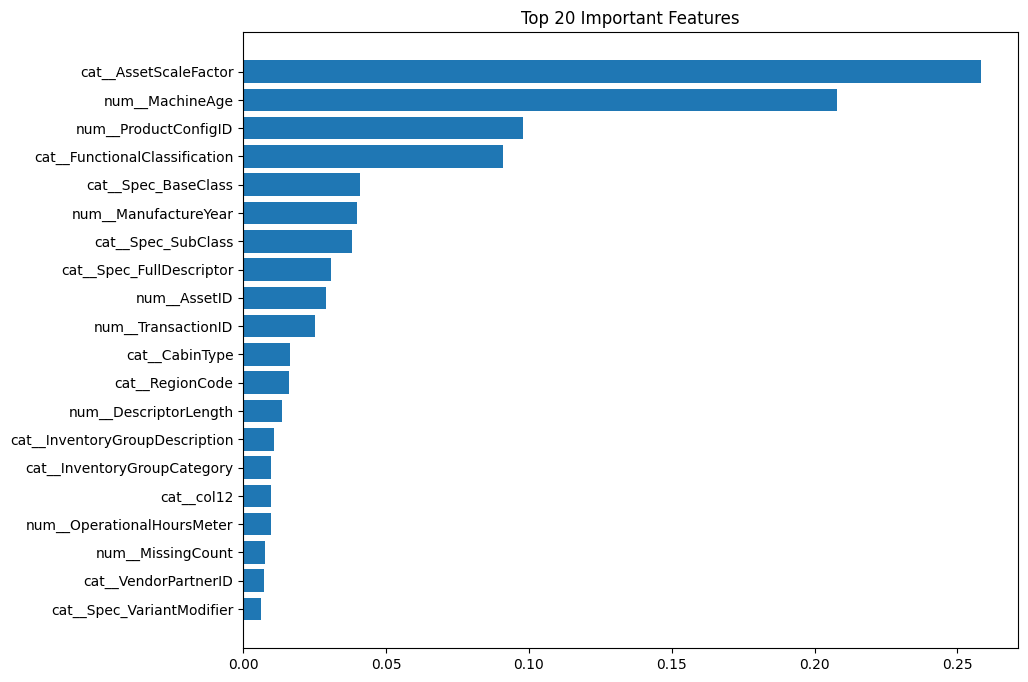

In [43]:
import matplotlib.pyplot as plt

top = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [44]:
X_full = preprocessor.fit_transform(X)
X_test = preprocessor.transform(test_df)

y_full = np.log1p(y)

rf.fit(
    X_full,
    y_full
)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [45]:
test_pred = np.expm1(
    rf.predict(X_test)
)

In [46]:
submission = ss.copy()

submission["TargetValue"] = test_pred

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,TransactionID,TargetValue
0,1139307,62805.293092
1,1139419,78372.178020
2,1139482,27674.770092
3,1139522,23149.478611
4,1139684,12370.055490


# Milestone 1

**Question 1 (MCQ):** Dataset Dimensions 

In [47]:
print("Train dataset rows:", train.shape[0])
print("Test dataset rows:", test.shape[0])

Train dataset rows: 138701
Test dataset rows: 15000


**Question 2 (MCQ):** Target Variable Identification 

In [48]:
set(train.columns) - set(test.columns)

{'TargetValue'}

**Question 3 (Numeric):** Feature Data Types

In [49]:
print(train.select_dtypes(include='number').shape[1])

6


**Question 4 (MSQ):** Extremely Sparse Columns 

In [50]:
missing_pct = train.isnull().mean() * 100

sparse_cols = missing_pct[missing_pct > 90]

print(f"Number of columns with >90% missing values: {len(sparse_cols)}")
print(sparse_cols.sort_values(ascending=False))

Number of columns with >90% missing values: 4
col19    99.952416
col18    99.952416
col5     92.515555
col4     92.515555
dtype: float64


**Question 5 (Numeric):** Missing Operational Metrics 

In [51]:
missing_count = train['OperationalHoursMeter'].isna().sum()
total_rows = len(train)

missing_pct = (missing_count / total_rows) * 100

print("Missing values:", missing_count)
print("Percentage missing:", round(missing_pct, 2), "%")

Missing values: 56643
Percentage missing: 40.84 %


**Question 6 (MCQ):** Target Value Distribution 

In [52]:
median_price = train['TargetValue'].median()
print(f"Median TargetValue: {median_price:,.0f}")

Median TargetValue: 35,000


**Question 7 (Numeric):** Manufacture Year Anomaly

In [53]:
train['ManufactureYear'].mode()

0    1001
Name: ManufactureYear, dtype: int64

**Question 8 (MCQ):** Time Span of Transactions 

In [54]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])

print(train['TransactionDate'].min())

1990-01-31 00:00:00


**Question 9 (Numeric):** High Cardinality Identification

In [55]:
train['Spec_BaseClass'].nunique()

1249

**Question 10 (MCQ):** Geographical Volume 

In [56]:
train['RegionCode'].value_counts()

RegionCode
Florida           23460
Texas             18284
California         9525
Washington         6063
Georgia            5240
North Carolina     4391
Maryland           4352
Mississippi        4227
Colorado           3989
Illinois           3855
Alabama            3723
Tennessee          3602
Ohio               3528
South Carolina     3386
New Jersey         3370
Arizona            3102
Connecticut        2860
Nevada             2730
Missouri           2531
Pennsylvania       2406
Minnesota          2377
Louisiana          2230
New York           2111
Utah               1518
Kentucky           1469
New Mexico         1360
Arkansas           1359
Indiana            1100
Virginia            941
Maine               928
Michigan            846
New Hampshire       822
Wisconsin           754
Idaho               742
Iowa                618
Oregon              603
Unspecified         586
Oklahoma            578
West Virginia       571
Montana             497
Wyoming             467
Nebra

**Question 11 (Numeric):** Regional Pricing Insights 

In [57]:
train[train['RegionCode'] == 'Florida']['TargetValue'].mean()

np.float64(45007.54262574595)

**Question 12 (MCQ):** Asset Utilization 

In [58]:
train['UtilizationTier'].value_counts()

UtilizationTier
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

**Question 13 (MCQ):** Operational Correlation

In [59]:
train[['TargetValue', 'OperationalHoursMeter']].corr(method='pearson')

,TargetValue,OperationalHoursMeter
TargetValue,1.000000,0.001994
OperationalHoursMeter,0.001994,1.000000


**Question 14 (MCQ):** Primary Equipment Types

In [60]:
train['FunctionalClassification'].mode()[0]

'Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons'

# Milestone 2

**Question 1**

In [61]:
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

In [62]:
train["TransactionYear"] = train["TransactionDate"].dt.year
train["TransactionQuarter"] = train["TransactionDate"].dt.quarter

In [63]:
train["AssetAge"] = train["TransactionYear"] - train["ManufactureYear"]

In [64]:
train["DescriptorLength"] = (
    train["Spec_FullDescriptor"]
    .fillna("")
    .astype(str)
    .str.len()
)

In [65]:
train["HasOperationalHours"] = train["OperationalHoursMeter"].notna().astype(int)
train["HasVariantModifier"] = train["Spec_VariantModifier"].notna().astype(int)

In [66]:
most_frequent_asset_age = train["AssetAge"].mode()[0]
print("Most frequent AssetAge:", most_frequent_asset_age)

Most frequent AssetAge: 5


**Question 2**

In [67]:
quarter_avg = train.groupby("TransactionQuarter")["TargetValue"].mean()
print("Average TargetValue by Quarter:")
print(quarter_avg.idxmax())

Average TargetValue by Quarter:
1


**Question 3**

In [68]:
print("Maximum DescriptorLength:", train["DescriptorLength"].max())

Maximum DescriptorLength: 19


**Question 4**

In [69]:
count_operational = train["HasOperationalHours"].sum()
print("HasOperationalHours = 1:", count_operational)

HasOperationalHours = 1: 82058


**Question 5**

In [70]:
variant_percent = train["HasVariantModifier"].mean() * 100
print("Percentage with Variant Info: {:.2f}%".format(variant_percent))

Percentage with Variant Info: 37.73%


**Question 6**

In [71]:
mean_year = train["ManufactureYear"].mean()
print("Mean ManufactureYear: {:.2f}".format(mean_year))

Mean ManufactureYear: 1891.64


**Question 7**

In [72]:
encoded = pd.get_dummies(
    train,
    columns=["RegionCode", "CabinType", "UtilizationTier"],
    drop_first=True
)

region_cols = pd.get_dummies(train["RegionCode"], drop_first=True).shape[1]
cabin_cols = pd.get_dummies(train["CabinType"], drop_first=True).shape[1]
util_cols = pd.get_dummies(train["UtilizationTier"], drop_first=True).shape[1]

total_encoded = region_cols + cabin_cols + util_cols

In [73]:
print("Encoded Columns Created:", total_encoded)

Encoded Columns Created: 56


**Question 8**

In [74]:
numeric_cols = train.select_dtypes(include=np.number)
corr = numeric_cols.corr(method="pearson")
target_corr = corr["TargetValue"].abs().sort_values(ascending=False)

In [75]:
print(target_corr)

TargetValue              1.000000
AssetID                  0.238719
HasVariantModifier       0.217434
AssetAge                 0.204698
ManufactureYear          0.204439
DescriptorLength         0.061502
ProductConfigID          0.057265
TransactionQuarter       0.034442
TransactionYear          0.024497
TransactionID            0.012093
HasOperationalHours      0.009653
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64


**Question 9**

In [76]:
features = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]

X = train[features].copy()
y = train["TargetValue"]

In [77]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [80]:
print("Training Shape:", X_train.shape)

Training Shape: (110960, 3)


**Question 10**

In [81]:
print("Validation Shape:", X_valid.shape)

Validation Shape: (27741, 3)


**Question 11**

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X2 = train[["ManufactureYear", "AssetAge"]]

X2 = SimpleImputer(strategy="mean").fit_transform(X2)
X2 = StandardScaler().fit_transform(X2)

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train2, y_train2)

pred = model.predict(X_valid2)

r2 = r2_score(y_valid2, pred)

print("R2 Score:", r2)

R2 Score: 0.04182681098431873
